<a href="https://colab.research.google.com/github/pratheekshashetty-blip/machinelearningprojects/blob/main/loan-approval/loan_approval_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loan Approval Prediction

dataset : https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

In [46]:
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:

from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score)

Loading the data

In [48]:
df= pd.read_csv('loan_approval_dataset.csv')


In [49]:
print(f'Shape of Dataset: {df.shape}')
print('\nDataset Preview (First 5 Rows):\n')
display(df.head())
print('\nDataset Preview (Last 5 Rows):\n')
display(df.tail())

Shape of Dataset: (4269, 13)

Dataset Preview (First 5 Rows):



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Dataset Preview (Last 5 Rows):



,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


Cleaning

In [50]:
df.columns = df.columns.str.strip()
df = df.drop('loan_id', axis=1)
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())

Checking for missing values

In [51]:
print("Missing Values in Data:", df.isnull().sum().sum())
print("Duplicated Values in Data:", df.duplicated().sum())

df.info()


Missing Values in Data: 0
Duplicated Values in Data: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [52]:
print("Numerical Statistics:")
display(df.describe().T)

print("\nCategorical Statistics:")
display(df.describe(include='object').T)

Numerical Statistics:


,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0



Categorical Statistics:


,count,unique,top,freq
education,4269,2,Graduate,2144
self_employed,4269,2,Yes,2150
loan_status,4269,2,Approved,2656


Exploratory Data Analysis

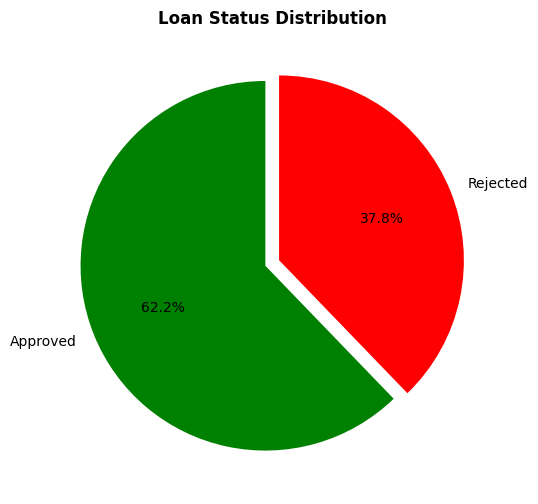

In [65]:
status_counts = df['loan_status'].value_counts()

# map labels
label_map = {0: 'Rejected', 1: 'Approved'}
labels = [label_map[i] for i in status_counts.index]

# colors aligned with labels
color_map = {'Rejected': 'red', 'Approved': 'green'}
colors = [color_map[label] for label in labels]

plt.figure(figsize=(10, 6))
explode = (0.04, 0.04)  # optional: highlight both slightly

plt.pie(
    x=status_counts.values,
    labels=labels,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.title('Loan Status Distribution', fontweight='bold')
plt.show()

In [68]:
df['loan_status_label'] = df['loan_status'].map({0: 'Rejected', 1: 'Approved'})

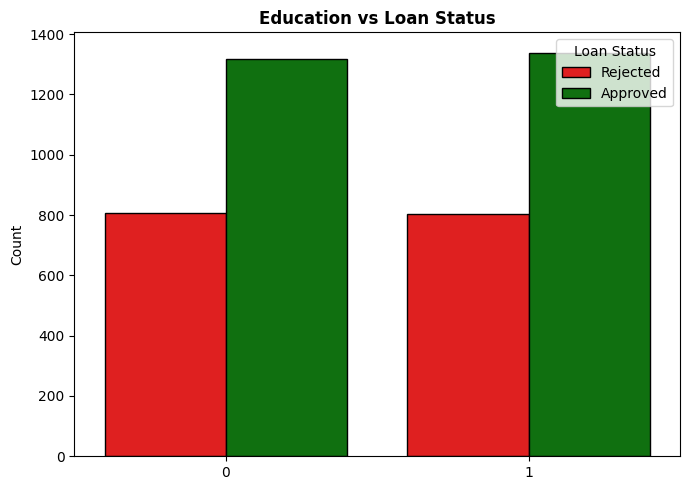

In [69]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df, x='education', hue='loan_status_label',
    edgecolor='k',
    palette={'Rejected': 'red', 'Approved': 'green'}
)
plt.title("Education vs Loan Status", fontweight='bold')
plt.ylabel("Count")
plt.xlabel("")
plt.legend(title="Loan Status", loc='upper right')
plt.tight_layout()
plt.show()

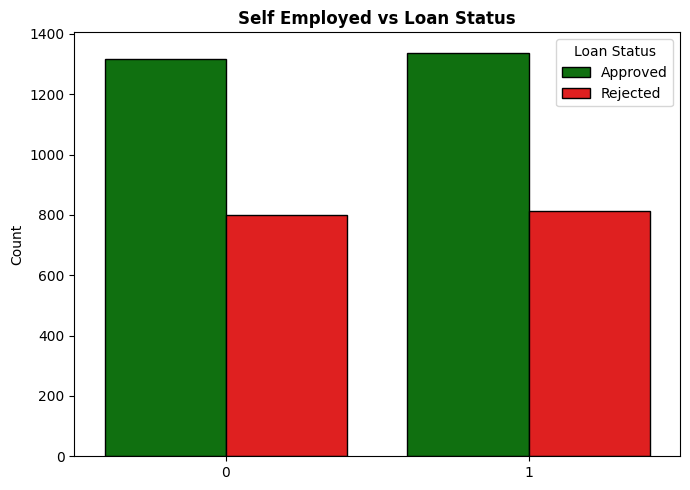

In [70]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df, x='self_employed', hue='loan_status_label',
    edgecolor='k',
    palette={'Rejected': 'red', 'Approved': 'green'}
)
plt.title("Self Employed vs Loan Status", fontweight='bold')
plt.ylabel("Count")
plt.xlabel("")
plt.legend(title="Loan Status", loc='upper right')
plt.tight_layout()
plt.show()

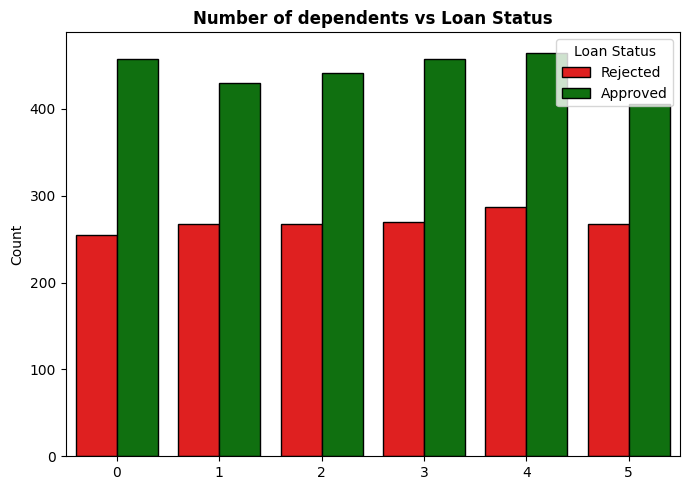

In [73]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df, x='no_of_dependents', hue='loan_status_label',
    edgecolor='k',
    palette={'Rejected': 'red', 'Approved': 'green'}
)
plt.title("Number of dependents vs Loan Status", fontweight='bold')
plt.ylabel("Count")
plt.xlabel("")
plt.legend(title="Loan Status", loc='upper right')
plt.tight_layout()
plt.show()

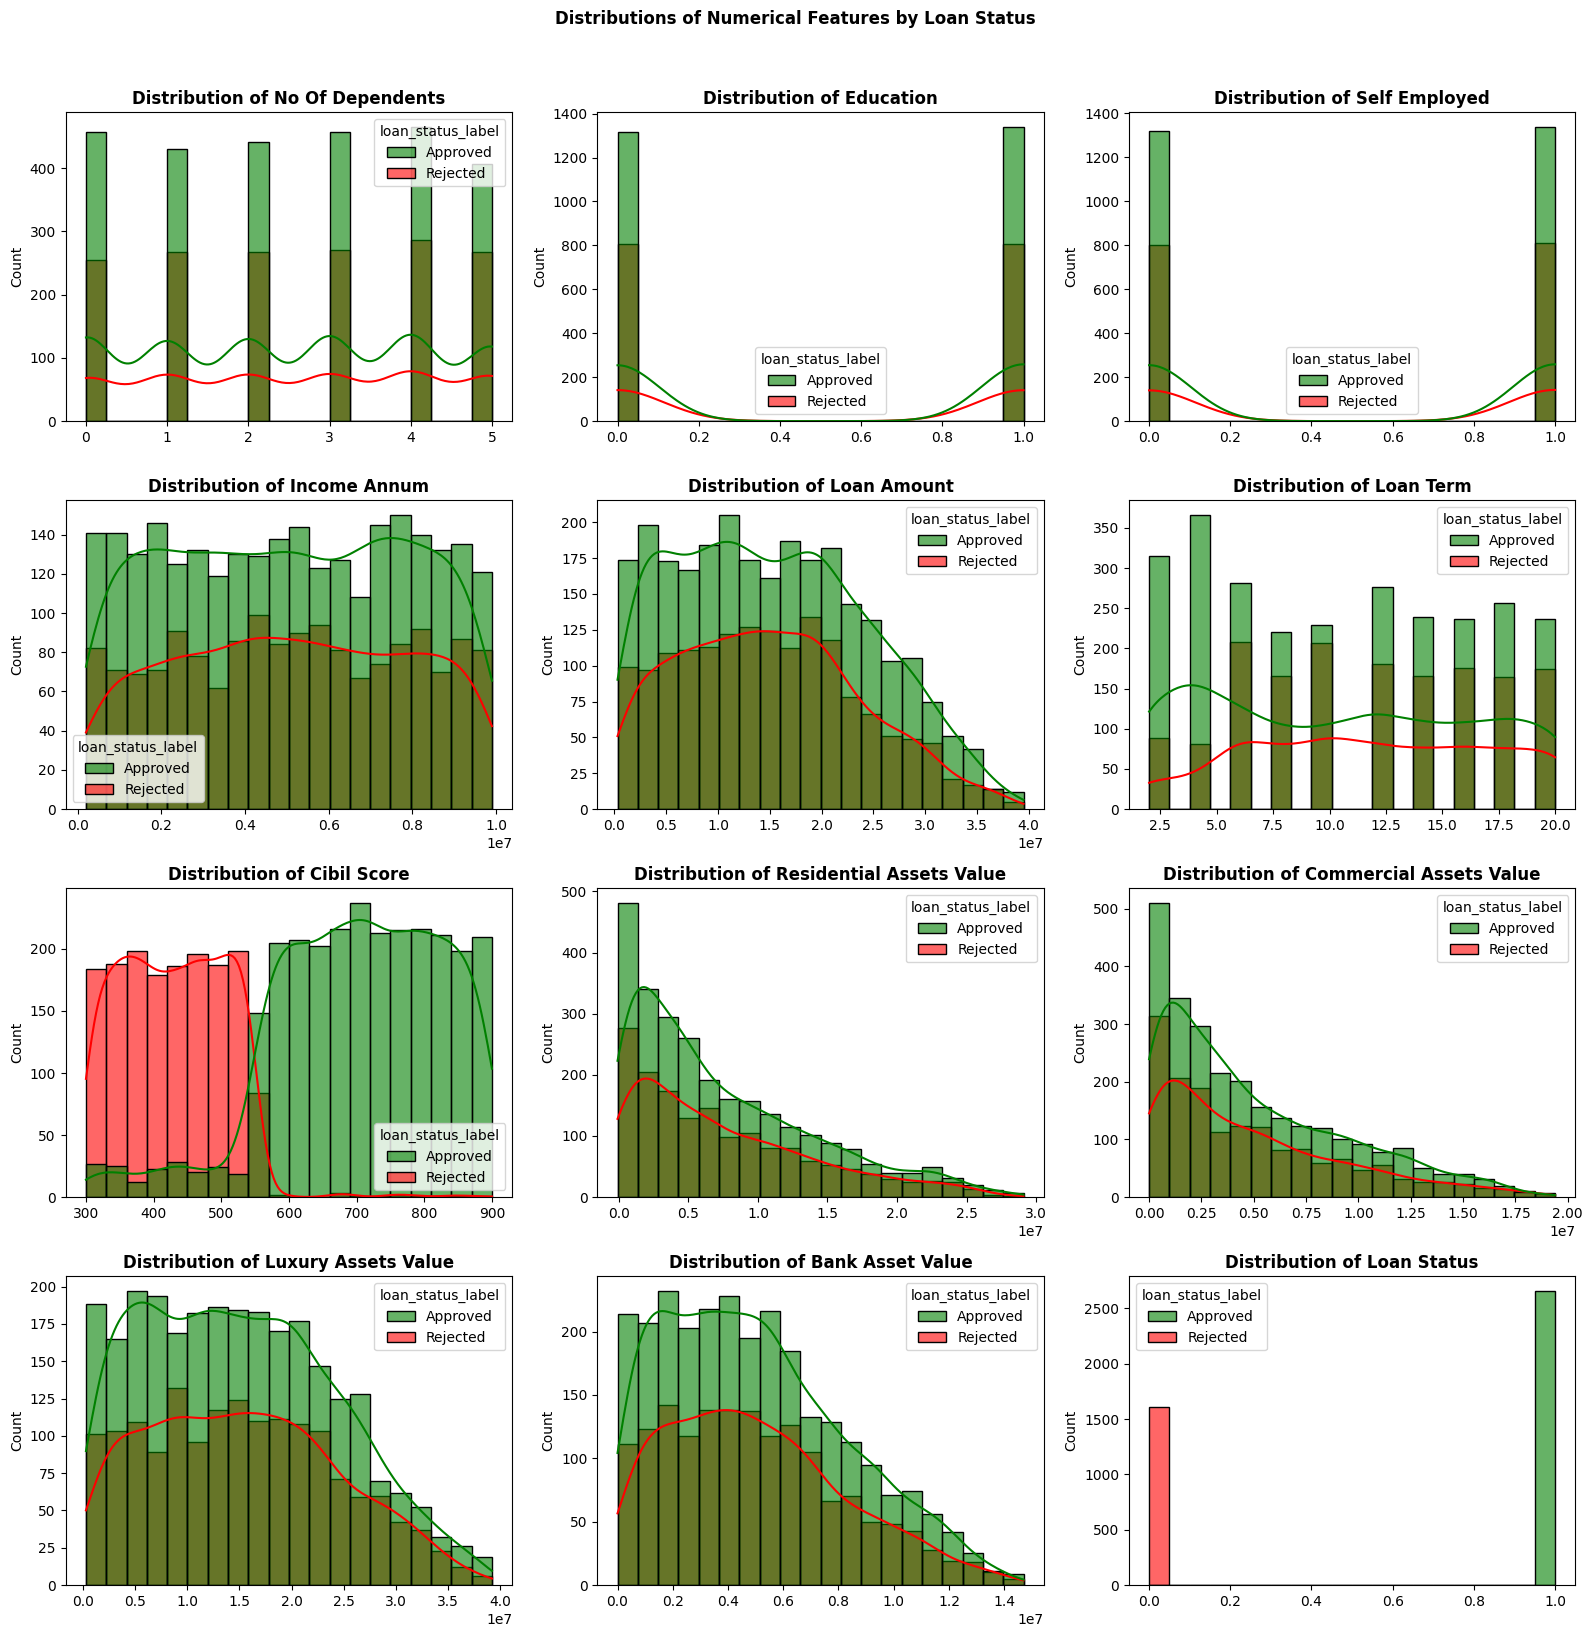

In [76]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='loan_status_label',
        kde=True,
        ax=axes[i],
        bins=20,
        alpha=0.6,
        edgecolor='k',
        palette={'Rejected': 'red', 'Approved': 'green'}
    )

    clean_title = col.replace('_', ' ').title()
    axes[i].set_title(f"Distribution of {clean_title}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Distributions of Numerical Features by Loan Status',
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

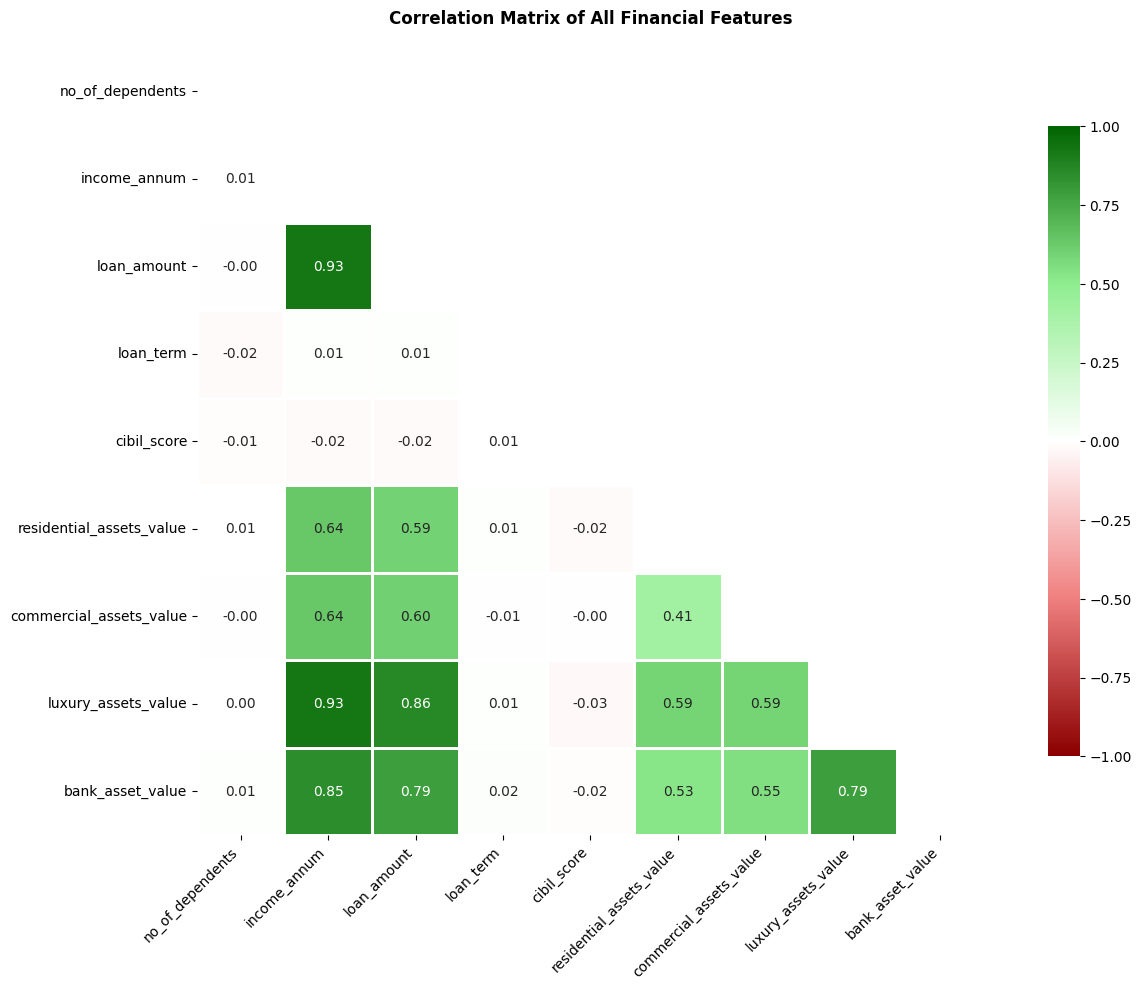

In [56]:
# Define a custom diverging colormap

custom_cmap = LinearSegmentedColormap.from_list("custom_diverging",
    ["darkred", "lightcoral", "white", "lightgreen", "darkgreen"])

plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask,
    annot=True, fmt=".2f",
    cmap=custom_cmap, vmin=-1, vmax=1,
    linewidths=1, linecolor='white',
    square=True, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of All Financial Features', fontweight='bold', y=1.02)
plt.xticks(rotation=45, ha='right')
plt.yticks()

plt.tight_layout()
plt.show()

Encoding Categorical Features

In [57]:
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})

X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split completed — Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}.")

Data split completed — Training rows: 3415, Testing rows: 854.


**SMOTE** (Synthetic Minority Over-sampling Technique) to ensure our models don't become biased toward the majority class.

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Target distribution before SMOTE (in training data):")
print(y_train.value_counts())
print("-" * 30)
print("Target distribution after SMOTE (perfect balance):")
print(y_train_smote.value_counts())

Target distribution before SMOTE (in training data):
loan_status
1    2125
0    1290
Name: count, dtype: int64
------------------------------
Target distribution after SMOTE (perfect balance):
loan_status
1    2125
0    2125
Name: count, dtype: int64


In [59]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_smote, y_train_smote)
y_pred_log = log_reg.predict(X_test_scaled)

tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_clf.fit(X_train_smote, y_train_smote)
y_pred_tree = tree_clf.predict(X_test_scaled)


rf_clf = RandomForestClassifier(random_state=42, max_depth=5, n_estimators=100)
rf_clf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_clf.predict(X_test_scaled)

In [60]:
target_labels = ['Rejected (0)', 'Approved (1)']
#Logistic Regression Performance
print("[1] Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log, target_names=target_labels))

#Decision  Tree Performance
print("\n[2] Decision Tree Performance:")
print(classification_report(y_test, y_pred_tree, target_names=target_labels))

#Random Forest Performance
print("\n[3] Random Forest Performance (Ensemble):")
print(classification_report(y_test, y_pred_rf, target_names=target_labels))

[1] Logistic Regression Performance:
              precision    recall  f1-score   support

Rejected (0)       0.88      0.92      0.90       323
Approved (1)       0.95      0.92      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.92      0.92       854
weighted avg       0.92      0.92      0.92       854


[2] Decision Tree Performance:
              precision    recall  f1-score   support

Rejected (0)       0.95      0.97      0.96       323
Approved (1)       0.98      0.97      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854


[3] Random Forest Performance (Ensemble):
              precision    recall  f1-score   support

Rejected (0)       0.95      0.99      0.97       323
Approved (1)       0.99      0.97      0.98       531

    accuracy                           0.97       854
   macro avg    

Feature importance

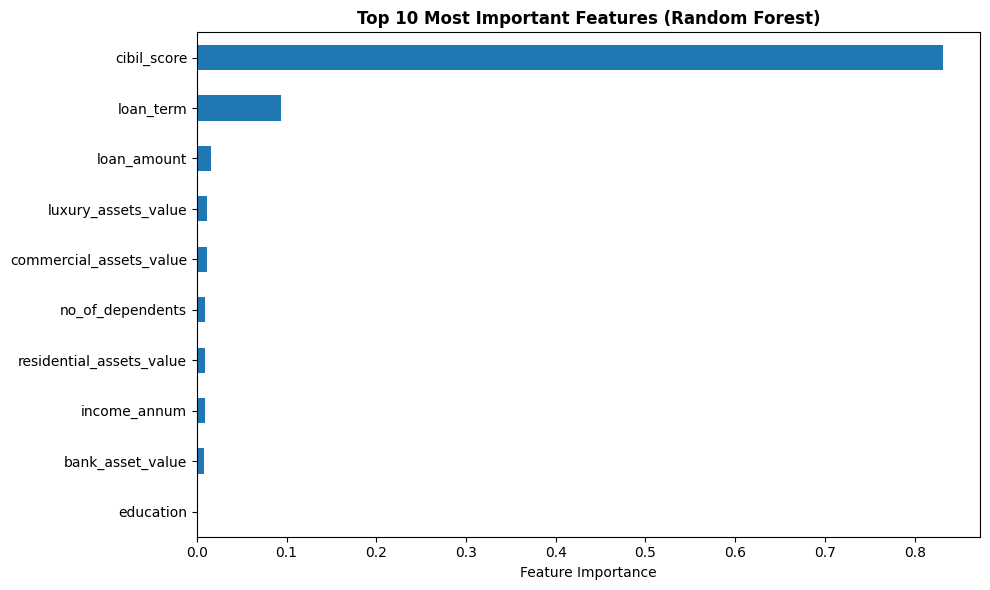

In [61]:
importances = rf_clf.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
pd.Series(importances, index=features).sort_values(ascending=False).head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Most Important Features (Random Forest)", fontweight='bold')
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

In [62]:
models = ['Logistic Regression','Decision Tree','Random Forest']
scores = [
log_reg.score(X_test_scaled,y_test),
tree_clf.score(X_test_scaled,y_test),
rf_clf.score(X_test_scaled,y_test)
]

pd.DataFrame({
'Model':models,
'Accuracy':scores
})

,Model,Accuracy
0,Logistic Regression,0.922717
1,Decision Tree,0.970726
2,Random Forest,0.974239


For this dataset Random Forest gives us the best result with accuracy of 0.974 other models like Decision Tree gives us 0.970 accuracy and Logistic Regression 0.922 accuracy.

Random Forest is recommended for deployment with 97.4% accuracy. However, real-world validation on new data is essential before production use. Future work should include cross-validation and threshold optimization for business-specific precision/recall trade-offs.

In [63]:
#Random Data Verification
import random

# Randomly test 5 applicants
for i in range(5):

    idx = random.randint(0, len(X_test) - 1)

    sample = X_test.iloc[[idx]]
    sample_scaled = scaler.transform(sample)

    prediction = rf_clf.predict(sample_scaled)[0]
    actual = y_test.iloc[idx]

    print("Applicant index:", idx)
    print("Predicted:", "Approved" if prediction == 1 else "Rejected")
    print("Actual:", "Approved" if actual == 1 else "Rejected")


Applicant index: 181
Predicted: Approved
Actual: Approved
Applicant index: 465
Predicted: Rejected
Actual: Rejected
Applicant index: 407
Predicted: Approved
Actual: Approved
Applicant index: 492
Predicted: Rejected
Actual: Rejected
Applicant index: 277
Predicted: Approved
Actual: Approved


In [77]:
# Loan Approval Predictor

print("Loan Approval Predictor")

dependents = int(input("Number of dependents: "))
education = int(input("Education (Graduate=1, Not Graduate=0): "))
self_employed = int(input("Self employed (Yes=1, No=0): "))
income = float(input("Annual income(In INR): "))
loan_amount = float(input("Loan amount requested: "))
loan_term = int(input("Loan term (years): "))
cibil = int(input("CIBIL score: "))
res_assets = float(input("Residential assets value: "))
com_assets = float(input("Commercial assets value: "))
lux_assets = float(input("Luxury assets value: "))
bank_assets = float(input("Bank asset value: "))

new_applicant = [[
    dependents,
    education,
    self_employed,
    income,
    loan_amount,
    loan_term,
    cibil,
    res_assets,
    com_assets,
    lux_assets,
    bank_assets
]]

new_applicant_scaled = scaler.transform(new_applicant)

prediction = rf_clf.predict(new_applicant_scaled)

print("\nLoan Decision:", "Approved" if prediction[0] == 1 else "Rejected")

Loan Approval Predictor
Number of dependents: 4
Education (Graduate=1, Not Graduate=0): 1
Self employed (Yes=1, No=0): 1
Annual income(In INR): 1000000
Loan amount requested: 9000000
Loan term (years): 6
CIBIL score: 800
Residential assets value: 500
Commercial assets value: 50400
Luxury assets value: 0
Bank asset value: 700000

Loan Decision: Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


The interactive Loan Approval Predictor allows real-time predictions on new applicants, making this model immediately deployable. This practical implementation validates our approach and demonstrates the model's readiness for production use.